## ANÁLISES VIROLÓGICAS DO SINAN


Este notebook realiza análises agregadas relacionadas
 aos sorotipos de dengue registrados no SINAN.
#
## Principais objetivos:
 - analisar a distribuição dos sorotipos no Brasil;
 - analisar a distribuição dos sorotipos por UF;
 - calcular a participação percentual de cada sorotipo;
 - avaliar a completude da informação de sorotipo;
 - produzir artefatos analíticos para etapas posteriores.


Estrutura para o 05_1_analises_virologicas_SINAN.ipynb:

1. Montagem do Drive
2. Imports
3. Configuração
4. Carregamento do SINAN enriquecido
5. Verificação das variáveis virológicas
6. Distribuição de sorotipos no Brasil
7. Distribuição de sorotipos por UF
8. Percentual de cada sorotipo por UF
9. Completude do sorotipo por UF
10. UFs com menor preenchimento de sorotipo
11. Panorama virológico nacional
12. Visualizações
13. Produtos virológicos finais
14. Inventário dos produtos
15. Salvamento
16. Validação dos arquivos

## 1 - Montagem do drive

In [1]:
from google.colab import drive
import os

drive.mount("/content/drive")

Mounted at /content/drive


##2 - Imports

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 3. Configuração

In [3]:
# ============================================================
# CONFIGURAÇÃO
# ============================================================

ANO = 2026

PASTA_BASE = Path(
    "/content/drive/MyDrive/Doutorado/arbovirus_rag"
)

PASTA_PROCESSED = (
    PASTA_BASE
    / "data_processed"
    / "SINAN"
    / str(ANO)
)

PASTA_ANALISES = (
    PASTA_BASE
    / "data_analytics"
    / "SINAN"
    / str(ANO)
)

PASTA_ANALISES.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_ENTRADA = (
    PASTA_PROCESSED
    / f"sinan_dengue_{ANO}_enriquecido.parquet"
)

# ============================================================
# DIRETÓRIO DE SAÍDA DOS PRODUTOS VIROLOGICOS
# ============================================================

PASTA_SAIDA = (
    PASTA_BASE
    / "data_analytics"
    / "SINAN"
    / str(ANO)
    / "virologicas"
)

PASTA_SAIDA.mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Pasta de saída:\n{PASTA_SAIDA}"
)

print(f"Ano: {ANO}")
print(f"Entrada: {ARQUIVO_ENTRADA}")
print(f"Saída: {PASTA_ANALISES}")

Pasta de saída:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/virologicas
Ano: 2026
Entrada: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_processed/SINAN/2026/sinan_dengue_2026_enriquecido.parquet
Saída: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026


## 4. Carregar o dataframe enriquecido

In [4]:
# ============================================================
# CARREGAMENTO
# ============================================================

df = pd.read_parquet(
    ARQUIVO_ENTRADA
)

print(
    f"Registros carregados: {len(df):,}"
)

print(
    f"Quantidade de variáveis: {df.shape[1]}"
)

display(
    df.head()
)

Registros carregados: 444,266
Quantidade de variáveis: 171


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W,SEMANA_EPIDEMIOLOGICA,ANO_SEM_NOT,UF_NAME,SOROTIPO_ANALITICO,HOSPITALIZ_ANALITICO,EVOLUCAO_ANALITICO,SOROTIPO_DECODED,HOSPITALIZ_DECODED,EVOLUCAO_DECODED,FEBRE_DECODED,MIALGIA_DECODED,CEFALEIA_DECODED,EXANTEMA_DECODED,VOMITO_DECODED,NAUSEA_DECODED,DOR_COSTAS_DECODED,CONJUNTVIT_DECODED,ARTRITE_DECODED,ARTRALGIA_DECODED,PETEQUIA_N_DECODED,LEUCOPENIA_DECODED,LACO_DECODED,DOR_RETRO_DECODED,DIABETES_DECODED,HEMATOLOG_DECODED,HEPATOPAT_DECODED,RENAL_DECODED,HIPERTENSA_DECODED,ACIDO_PEPT_DECODED,AUTO_IMUNE_DECODED,TPAUTOCTO_DECODED,COUFINF_NORMALIZADO,COMUNINF_NORMALIZADO,CODIGO_MUNICIPIO_6,CODIGO_MUNICIPIO_7,MUNICIPIO_NAME,UF_RESIDENCIA,CODIGO_UF_IBGE,REGIAO,POPULACAO_2022,LATITUDE,LONGITUDE,IS_CAPITAL,PIB_PER_CAPITA_2021,COD_MUNICIPIO_PROVAVEL_INFECCAO,MUNICIPIO_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO,COD_UF_PROVAVEL_INFECCAO,REGIAO_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO_CONSISTENTE
0,2,A90,2026-05-19,202620,2026,32,320400,32001,2448653,2026-05-14,202619,1978,4048,F,5,1,8,32,320400,32001,1,2026-05-18,251605,1,1,2,1,2,1,1,2,2,1,1,1,2,1,2,2,2,2,2,2,2,None,None,None,0,0,0,None,4,2026-05-18,1,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,1,0,1,1,None,2026-05-25,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-11-08,0,0,0,20,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Não,Sim,Não,Sim,Sim,Não,Não,Sim,Sim,Sim,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320400,3204005,Pancas,ES,32,Sudeste,18893.0,-19.2229,-40.8534,0.0,16755.0,<NA>,None,None,<NA>,None,None
1,2,A90,2026-01-05,202601,2026,32,320500,32002,2499495,2026-01-04,202601,1984,4041,F,5,4,5,32,320500,32002,1,2026-01-05,0,1,1,1,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,1,2,2,None,None,None,0,0,0,None,4,2026-01-05,2,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Sim,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0,<NA>,None,None,<NA>,None,None
2,2,A90,2026-01-05,202601,2026,32,320500,32002,2522772,2026-01-05,202601,1991,4034,F,5,2,6,32,320500,32002,1,2026-01-05,322215,1,2,1,2,1,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,None,None,None,0,0,0,None,0,1920-01-05,2,None,4,None,0,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Não,Sim,Não,Sim,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0,<NA>,None,None,<NA>,None,None
3,2,A90,2026-01-05,202601,2026,32,320500,32002,7838131,2026-

##5. verificação rápida das variáveis virológicas essenciais:

In [5]:
# ============================================================
# VARIÁVEIS NECESSÁRIAS ÀS ANÁLISES VIROLÓGICAS
# ============================================================

VARIAVEIS_VIROLOGICAS = [
    "NU_ANO",
    "SG_UF_NOT",
    "UF_NAME",
    "SOROTIPO",
    "SOROTIPO_DECODED"
]

verificacao_virologica = pd.DataFrame({
    "VARIAVEL": VARIAVEIS_VIROLOGICAS,
    "EXISTE": [
        coluna in df.columns
        for coluna in VARIAVEIS_VIROLOGICAS
    ]
})

display(verificacao_virologica)

,VARIAVEL,EXISTE
0,NU_ANO,True
1,SG_UF_NOT,True
2,UF_NAME,True
3,SOROTIPO,True
4,SOROTIPO_DECODED,True


In [6]:
variaveis_ausentes = (
    verificacao_virologica.loc[
        ~verificacao_virologica["EXISTE"],
        "VARIAVEL"
    ]
    .tolist()
)

if variaveis_ausentes:
    raise ValueError(
        "Variáveis necessárias não encontradas: "
        + ", ".join(variaveis_ausentes)
    )

print(
    "OK — todas as variáveis necessárias "
    "às análises virológicas estão disponíveis."
)

OK — todas as variáveis necessárias às análises virológicas estão disponíveis.


## 6 e 7. Sorotipos por UF

Para sorotipos trabalharemos com UF de notificação

### Distribuição dos sorotipos por Unidade Federativa

Esta análise contabiliza os registros de dengue segundo o sorotipo viral
identificado e a Unidade Federativa de notificação.

São considerados nesta agregação somente os registros em que a variável
`SOROTIPO_DECODED` possui informação disponível.

A análise permite identificar quais sorotipos foram registrados em cada UF,
bem como comparar sua frequência entre as diferentes unidades federativas.

A ausência de informação sobre sorotipo é analisada separadamente por meio
de indicadores de completude, evitando interpretar registros sem informação
laboratorial como ausência de circulação de determinado sorotipo.

In [7]:
# ============================================================
# DISTRIBUIÇÃO DE SOROTIPOS POR UF
# ============================================================

sorotipos_por_uf = (
    df.loc[
        df[
            "SOROTIPO_DECODED"
        ].notna()
    ]
    .groupby(
        [
            "NU_ANO",
            "SG_UF_NOT",
            "UF_NAME",
            "SOROTIPO_DECODED"
        ]
    )
    .size()
    .reset_index(
        name="TOTAL_CASOS"
    )
)

display(
    sorotipos_por_uf.sort_values(
        [
            "UF_NAME",
            "TOTAL_CASOS"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,NU_ANO,SG_UF_NOT,UF_NAME,SOROTIPO_DECODED,TOTAL_CASOS
4,2026,12,Acre,DENV-1,81
5,2026,12,Acre,DENV-3,2
43,2026,27,Alagoas,DENV-2,486
44,2026,27,Alagoas,DENV-3,220
42,2026,27,Alagoas,DENV-1,88
6,2026,13,Amazonas,DENV-1,50
7,2026,13,Amazonas,DENV-2,8
49,2026,29,Bahia,DENV-2,531
50,2026,29,Bahia,DENV-3,95
48,2026,29,Bahia,DENV-1,59


Aqui é importante não eliminar silenciosamente a ausência de sorotipo da análise geral. Esse dataframe passa a responder diretamente questões de competência como:

* Quais UFs apresentam menor percentual de registros com sorotipo informado?

* Quais UFs apresentam maior percentual de registros com sorotipo informado?

* Qual é o percentual de registros com sorotipo informado em cada UF?

* Quais UFs apresentam maior incompletude na informação sobre sorotipo?

E há uma distinção importante para seus documentos semânticos futuros:

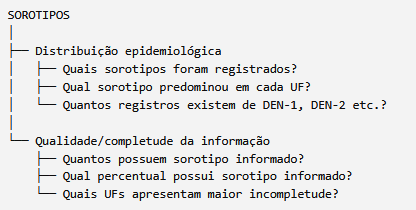

##7, 8, 9 e 10 - Completude do sorotipo por UF

In [8]:
# ============================================================
# COMPLETUDE DO SOROTIPO POR UF
# ============================================================

completude_sorotipo_uf = (
    df.groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    )
    .agg(
        TOTAL_REGISTROS=(
            "SOROTIPO_DECODED",
            "size"
        ),
        SOROTIPO_INFORMADO=(
            "SOROTIPO_DECODED",
            "count"
        )
    )
    .reset_index()
)

completude_sorotipo_uf[
    "SOROTIPO_NAO_INFORMADO"
] = (
    completude_sorotipo_uf["TOTAL_REGISTROS"]
    -
    completude_sorotipo_uf["SOROTIPO_INFORMADO"]
)

completude_sorotipo_uf[
    "PERCENTUAL_SOROTIPO_INFORMADO"
] = (
    completude_sorotipo_uf["SOROTIPO_INFORMADO"]
    /
    completude_sorotipo_uf["TOTAL_REGISTROS"]
    * 100
).round(2)

completude_sorotipo_uf[
    "PERCENTUAL_SOROTIPO_NAO_INFORMADO"
] = (
    completude_sorotipo_uf["SOROTIPO_NAO_INFORMADO"]
    /
    completude_sorotipo_uf["TOTAL_REGISTROS"]
    * 100
).round(2)

display(
    completude_sorotipo_uf.sort_values(
        "PERCENTUAL_SOROTIPO_INFORMADO"
    )
)

,SG_UF_NOT,UF_NAME,TOTAL_REGISTROS,SOROTIPO_INFORMADO,SOROTIPO_NAO_INFORMADO,PERCENTUAL_SOROTIPO_INFORMADO,PERCENTUAL_SOROTIPO_NAO_INFORMADO
5,16,Amapá,513,0,513,0.00,100.00
22,43,Rio Grande do Sul,6743,69,6674,1.02,98.98
19,35,São Paulo,65195,935,64260,1.43,98.57
8,22,Piauí,17383,296,17087,1.70,98.30
10,24,Rio Grande do Norte,7234,156,7078,2.16,97.84
26,53,Distrito Federal,3841,104,3737,2.71,97.29
15,29,Bahia,21609,687,20922,3.18,96.82
7,21,Maranhão,12282,400,11882,3.26,96.74
2,13,Amazonas,1399,58,1341,4.15,95.85
20,41,Paraná,11293,504,10789,4.46,95.54


## 11 e 12 - Panorama virológico nacional e visualizações

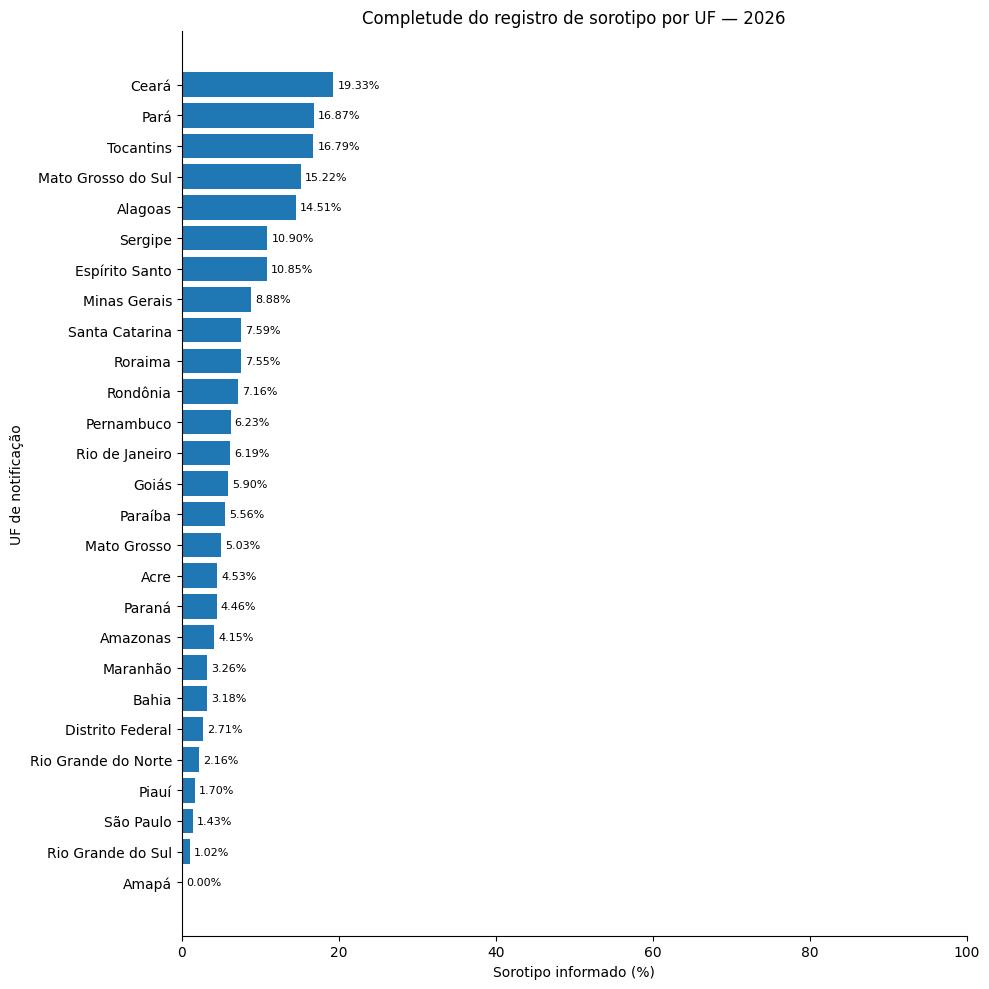

In [9]:
# ============================================================
# GRÁFICO — COMPLETUDE DO SOROTIPO POR UF
# ============================================================

import matplotlib.pyplot as plt

dados_grafico = (
    completude_sorotipo_uf
    .sort_values(
        "PERCENTUAL_SOROTIPO_INFORMADO",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 10)
)

barras = ax.barh(
    dados_grafico["UF_NAME"],
    dados_grafico["PERCENTUAL_SOROTIPO_INFORMADO"]
)

ax.set_title(
    f"Completude do registro de sorotipo por UF — {ANO}"
)

ax.set_xlabel(
    "Sorotipo informado (%)"
)

ax.set_ylabel(
    "UF de notificação"
)

ax.set_xlim(
    0,
    100
)

# Adicionar percentual ao final das barras
ax.bar_label(
    barras,
    labels=[
        f"{valor:.2f}%"
        for valor in dados_grafico[
            "PERCENTUAL_SOROTIPO_INFORMADO"
        ]
    ],
    padding=3,
    fontsize=8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

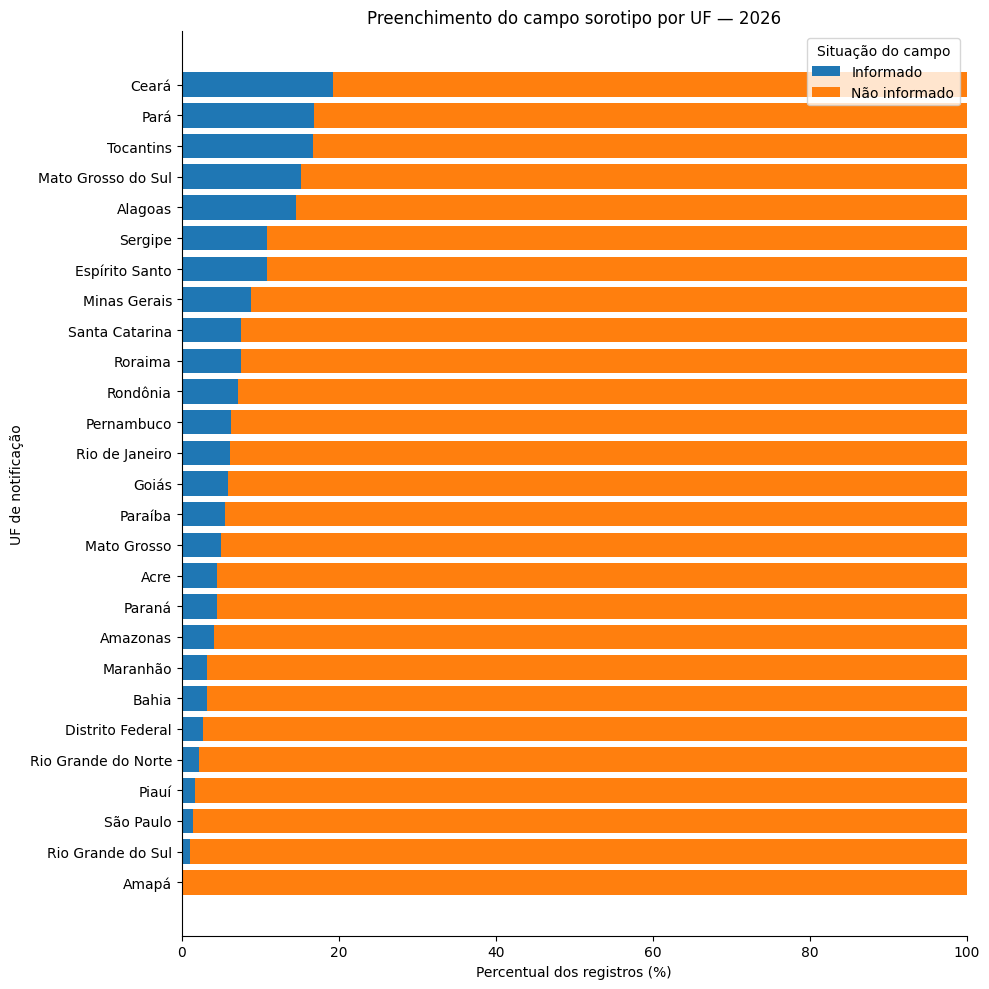

In [10]:
# ============================================================
# GRÁFICO — SOROTIPO INFORMADO E NÃO INFORMADO POR UF
# ============================================================

dados_grafico = (
    completude_sorotipo_uf
    .sort_values(
        "PERCENTUAL_SOROTIPO_INFORMADO",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 10)
)

ax.barh(
    dados_grafico["UF_NAME"],
    dados_grafico["PERCENTUAL_SOROTIPO_INFORMADO"],
    label="Informado"
)

ax.barh(
    dados_grafico["UF_NAME"],
    dados_grafico["PERCENTUAL_SOROTIPO_NAO_INFORMADO"],
    left=dados_grafico["PERCENTUAL_SOROTIPO_INFORMADO"],
    label="Não informado"
)

ax.set_title(
    f"Preenchimento do campo sorotipo por UF — {ANO}"
)

ax.set_xlabel(
    "Percentual dos registros (%)"
)

ax.set_ylabel(
    "UF de notificação"
)

ax.set_xlim(
    0,
    100
)

ax.legend(
    title="Situação do campo"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

## 13. Produtos virológicos finais

Aqui reunimos os DataFrames finais que queremos disponibilizar para as próximas etapas.

Assumindo que foi gerado:

- sorotipos_brasil
- sorotipos_por_uf
- distribuicao_sorotipos_uf
- completude_sorotipo_uf

In [11]:
# ============================================================
# PRODUTOS VIROLÓGICOS FINAIS
# ============================================================

PRODUTOS_VIROLOGICOS = {

    # Quantidade de registros de sorotipo por UF
    "sorotipos_uf": sorotipos_por_uf,

    # Completude do campo sorotipo por UF
    "completude_sorotipo_uf": completude_sorotipo_uf
}

print(
    f"Produtos virológicos definidos: "
    f"{len(PRODUTOS_VIROLOGICOS)}"
)

Produtos virológicos definidos: 2


## 14. Inventário dos produtos

In [12]:
# ============================================================
# INVENTÁRIO DOS PRODUTOS VIROLÓGICOS
# ============================================================

DESCRICOES_PRODUTOS_VIROLOGICOS = {

    "sorotipos_uf":
        "Quantidade de registros de cada sorotipo de dengue "
        "segundo UF de notificação.",


    "completude_sorotipo_uf":
        "Quantidade e percentual de registros com sorotipo "
        "informado e não informado por UF."
}

In [13]:
inventario_produtos_virologicos = []

for nome, produto in PRODUTOS_VIROLOGICOS.items():

    inventario_produtos_virologicos.append({
        "PRODUTO": nome,
        "DESCRICAO": DESCRICOES_PRODUTOS_VIROLOGICOS.get(
            nome,
            ""
        ),
        "REGISTROS": len(produto),
        "COLUNAS": len(produto.columns)
    })

inventario_produtos_virologicos = pd.DataFrame(
    inventario_produtos_virologicos
)

display(
    inventario_produtos_virologicos
)

,PRODUTO,DESCRICAO,REGISTROS,COLUNAS
0,sorotipos_uf,Quantidade de registros de cada sorotipo de de...,90,5
1,completude_sorotipo_uf,Quantidade e percentual de registros com sorot...,27,7


## 15. Salvamento

In [14]:
# ============================================================
# SALVAMENTO DOS PRODUTOS VIROLÓGICOS
# ============================================================

arquivos_salvos = []

for nome, produto in PRODUTOS_VIROLOGICOS.items():

    caminho = (
        PASTA_SAIDA
        / f"{nome}_{ANO}.parquet"
    )

    produto.to_parquet(
        caminho,
        index=False
    )

    arquivos_salvos.append(caminho)

    print(
        f"Salvo: {caminho.name}"
    )

print(
    f"\nTotal de produtos salvos: "
    f"{len(arquivos_salvos)}"
)

Salvo: sorotipos_uf_2026.parquet
Salvo: completude_sorotipo_uf_2026.parquet

Total de produtos salvos: 2


In [15]:
# ============================================================
# SALVAMENTO DO INVENTÁRIO
# ============================================================

caminho_inventario = (
    PASTA_SAIDA
    / f"inventario_produtos_virologicos_{ANO}.csv"
)

inventario_produtos_virologicos.to_csv(
    caminho_inventario,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Inventário salvo: "
    f"{caminho_inventario.name}"
)

Inventário salvo: inventario_produtos_virologicos_2026.csv


## 16. Validação dos arquivos

- o arquivo existe;
- pode ser recarregado;
- possui a mesma quantidade de registros;
- possui as mesmas colunas.

In [16]:
# ============================================================
# VALIDAÇÃO DOS ARQUIVOS VIROLÓGICOS
# ============================================================

validacao_arquivos_virologicos = []

for nome, produto_original in PRODUTOS_VIROLOGICOS.items():

    caminho = (
        PASTA_SAIDA
        / f"{nome}_{ANO}.parquet"
    )

    try:

        produto_recarregado = pd.read_parquet(
            caminho
        )

        mesmas_linhas = (
            len(produto_original)
            == len(produto_recarregado)
        )

        mesmas_colunas = (
            list(produto_original.columns)
            == list(produto_recarregado.columns)
        )

        valido = (
            caminho.exists()
            and mesmas_linhas
            and mesmas_colunas
        )

        validacao_arquivos_virologicos.append({
            "PRODUTO": nome,
            "ARQUIVO_EXISTE": caminho.exists(),
            "REGISTROS_ORIGINAL": len(produto_original),
            "REGISTROS_ARQUIVO": len(produto_recarregado),
            "MESMOS_REGISTROS": mesmas_linhas,
            "MESMAS_COLUNAS": mesmas_colunas,
            "VALIDO": valido
        })

    except Exception as erro:

        validacao_arquivos_virologicos.append({
            "PRODUTO": nome,
            "ARQUIVO_EXISTE": caminho.exists(),
            "REGISTROS_ORIGINAL": len(produto_original),
            "REGISTROS_ARQUIVO": None,
            "MESMOS_REGISTROS": False,
            "MESMAS_COLUNAS": False,
            "VALIDO": False
        })

        print(
            f"Erro ao validar {nome}: {erro}"
        )

validacao_arquivos_virologicos = pd.DataFrame(
    validacao_arquivos_virologicos
)

display(
    validacao_arquivos_virologicos
)

,PRODUTO,ARQUIVO_EXISTE,REGISTROS_ORIGINAL,REGISTROS_ARQUIVO,MESMOS_REGISTROS,MESMAS_COLUNAS,VALIDO
0,sorotipos_uf,True,90,90,True,True,True
1,completude_sorotipo_uf,True,27,27,True,True,True


In [17]:
# ============================================================
# RESULTADO FINAL
# ============================================================

if validacao_arquivos_virologicos["VALIDO"].all():

    print("=" * 70)
    print("ANÁLISES VIROLÓGICAS CONCLUÍDAS COM SUCESSO")
    print("=" * 70)

    print(
        f"\nProdutos gerados: "
        f"{len(PRODUTOS_VIROLOGICOS)}"
    )

    print(
        f"Arquivos validados: "
        f"{validacao_arquivos_virologicos['VALIDO'].sum()}"
    )

    print(
        f"\nDiretório:\n{PASTA_SAIDA}"
    )

else:

    print("=" * 70)
    print("ATENÇÃO — FORAM ENCONTRADOS PROBLEMAS")
    print("=" * 70)

    display(
        validacao_arquivos_virologicos[
            ~validacao_arquivos_virologicos["VALIDO"]
        ]
    )

ANÁLISES VIROLÓGICAS CONCLUÍDAS COM SUCESSO

Produtos gerados: 2
Arquivos validados: 2

Diretório:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/virologicas
